MAP fitter for RFI time series. Heavily WIP.

In [1]:
##Importing packages
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
from SSINS import INS
import os
import scipy.linalg as la
from scipy.signal.windows import dpss
from scipy.optimize import minimize
from custom_funcs import chan_select, chan_avg
import corner

In [2]:
##Calling in the night
data_dir = "Data"
night = "109328_p1"
datapath = os.path.join(data_dir, night + "_SSINS_data.h5")

ins = INS(datapath, telescope_name='MWA')

#Shape dictionary
TV_dict = {
    'TV6': [1.74e8, 1.81e8],
    'TV7': [1.81e8, 1.88e8],
    'TV8': [1.88e8, 1.95e8],
    'TV9': [1.95e8, 2.02e8]
    }

##Selecting one DTV subband
chan_name = 'TV7'

##Extracting and averaging over the selected subband
ins_subband, masked_ins, N_bl, N_freq = chan_select(ins, chan_name, TV_dict)
time, amp = chan_avg(ins_subband)
masked_time, masked_amp = chan_avg(masked_ins)

invalid value encountered in multiply
invalid value encountered in divide
sig_array has been reset


In [3]:
#Peaks, amplitudes (arb. units)
peaks=np.array([53.35432366, 8.97030183, 39.32910956, 28.3103236, 30.93772398, 36.2624972, 15.55913153, 44.21889192,
       44.9823896, 36.18116225, 25.08418434, 33.37233714, 51.98871383, 71.11015838, 25.76393398, 17.09304232, 
       6.0885566, 11.14962293, 52.29949963, 44.91604231, 23.85311619, 57.59864797, 1.21500878e+01, 4.57578285e+01,
       43.16161392, 51.0379999, 16.44774823, 53.31619823, 85.09920858, 10.72147938, 18.26272233, 37.61133042,
       11.1810082, 12.82857739, 51.49711535, 20.3400262, 34.50876787, 46.37546283, 35.81477314, 36.96341681,
       9.18631159, 33.3049884, 6.10809826, 18.75778949, 26.21931248, 46.57467886, 22.82709187, 18.69584422,
       56.140001, 66.05041274, 61.65063534, 5.5279846, 7.64796047, 59.34091678, 63.71339591, 38.23994538])

#Time into pointing/length of pointing
loc=np.array([0.39361857, 0.94595976, 0.52309947, 0.1174075, 0.42087645, 0.55030397, 0.96448721, 0.95354939,
     0.5667833, 0.9647058, 0.13256501, 0.52036559, 0.18725956, 0.53959978, 0.81926798, 0.85710116, 
     0.19789189, 0.56327705, 0.62144842, 0.11526984, 0.44578389, 0.15972674, 1.84629939e-01, 8.81903585e-01,
     2.53746154e-01, 3.52378053e-01, 6.56658287e-01, 0.20640947, 0.9842502, 0.82448753, 0.79864468, 0.82609582,
     0.11022169, 0.07753185, 0.57244621, 0.0896191, 0.64090821, 0.4027631, 0.24795562, 0.72001842,
     0.10122139, 0.25738608, 0.64577568, 0.68554986, 0.45178244, 0.82402821, 0.16167855, 0.25189232,
     0.45948544, 0.53000544, 0.94603795, 0.41958575, 0.94060631, 0.4551634, 0.96417559, 0.68670813])

#Durations (s)
widths=np.array([46.35740966, 47.78082138, 52.01985143, 51.1243677, 48.66579981, 62.63576724, 51.55184647, 64.54810228,
        68.97618067, 63.08569669, 56.8891352, 64.68566024, 54.74073774, 57.955234, 35.92143505, 32.08070818,
        74.16922759, 57.12015228, 69.59804093, 65.70437593, 47.97567077, 82.01174163, 6.44723034e+01, 6.44048269e+01,
        6.87384350e+01, 6.99024843e+01, 5.66360677e+01, 73.41190595, 97.88771772, 38.34149624, 40.48260042, 62.84866352,
        39.34094184, 43.88357933, 68.20029216, 55.17499495, 59.64828645, 65.16642306, 59.59367969, 57.69014685,
        39.30030286, 25.61981977, 60.45653745, 36.25104968, 50.26782436, 66.64052355, 64.69421242, 35.47301949,
        57.35702717, 62.72083288, 57.83072425, 72.39670654, 7.68408292e+01, 56.47607773, 58.60065642, 58.92762818])

#Redimensioning
widths = np.sort(widths)/60/60/24
loc = np.sort(loc)
peaks = np.sort(peaks)

In [4]:
##Setting up initial guesses for the converger
theta_0 = np.vstack((peaks, loc*(np.max(time) - np.min(time)), widths))
emit_cov = la.block_diag(*[np.cov(theta_0[[0, 2]])] * 3)

In [5]:
def DPSS_fit(time, masked_time, masked_amp, N_win=4, N_terms=13, N_bl=N_bl, N_freq=N_freq):
    
    '''The DPSS basis fitting function. Used to fit smooth background to masked data.

    Args:
        time            -- Numpy unmasked time array.
        masked_time     -- Numpy masked time array.
        masked_amp      -- Numpy masked visibility amplitudes array.
        N_win           -- Half-bandwidth in the DPSS basis. See scipy.signal.windows.dpss for documentation.
        N_terms         -- Number of terms you want in the DPSS basis.
        N_bl            -- Number of baselines you're averaging over.
        N_freq          -- Number of frequency bins you're averaging over. '''

    #Sorting indices in case they got messed up somewhere.
    sort_ind = np.argsort(masked_time)
    masked_time = np.array(masked_time[sort_ind])
    masked_amp = np.array(masked_amp[sort_ind])

    #Generating uniform time grid
    dt = st.mode(np.diff(masked_time)).mode
    smooth_time = np.arange(time.min(), time.max() + dt, dt)

    #Padding amplitude arrays with NaN
    masked_padded_amp = np.full_like(smooth_time, np.nan, dtype=float)
    masked_indices = np.searchsorted(smooth_time, masked_time)
    masked_padded_amp[masked_indices] = masked_amp

    #Generating DPSS design matrix
    M = len(smooth_time)
    design = dpss(M, N_win, Kmax=N_terms, return_ratios=True)[0].T

    #Constructing least-squares DPSS coefficients
    observed_indices = ~np.isnan(masked_padded_amp)
    splice_design = design[observed_indices, :]
    coefficients = la.solve(splice_design.T @ splice_design, splice_design.T @ masked_padded_amp[observed_indices])
    fit = design @ coefficients     #Main return of the DPSS_fit function
    
    #Finding the noise covariances
    mu = splice_design @ coefficients
    C = 4/np.pi-1
    noise_cov = np.diag((fit ** 2) * C / (N_bl * N_freq))
    splice_noise_cov = np.diag((mu ** 2) * C / (N_bl * N_freq))

    #Finding the parameter covariance
    sigma_p = la.solve(splice_design.T @ la.solve(splice_noise_cov, splice_design), np.eye(splice_design.shape[1]))

    #Finding the fit covariance
    sigma_f = design @ sigma_p @ design.T

    return fit, coefficients, smooth_time, noise_cov, sigma_p, sigma_f

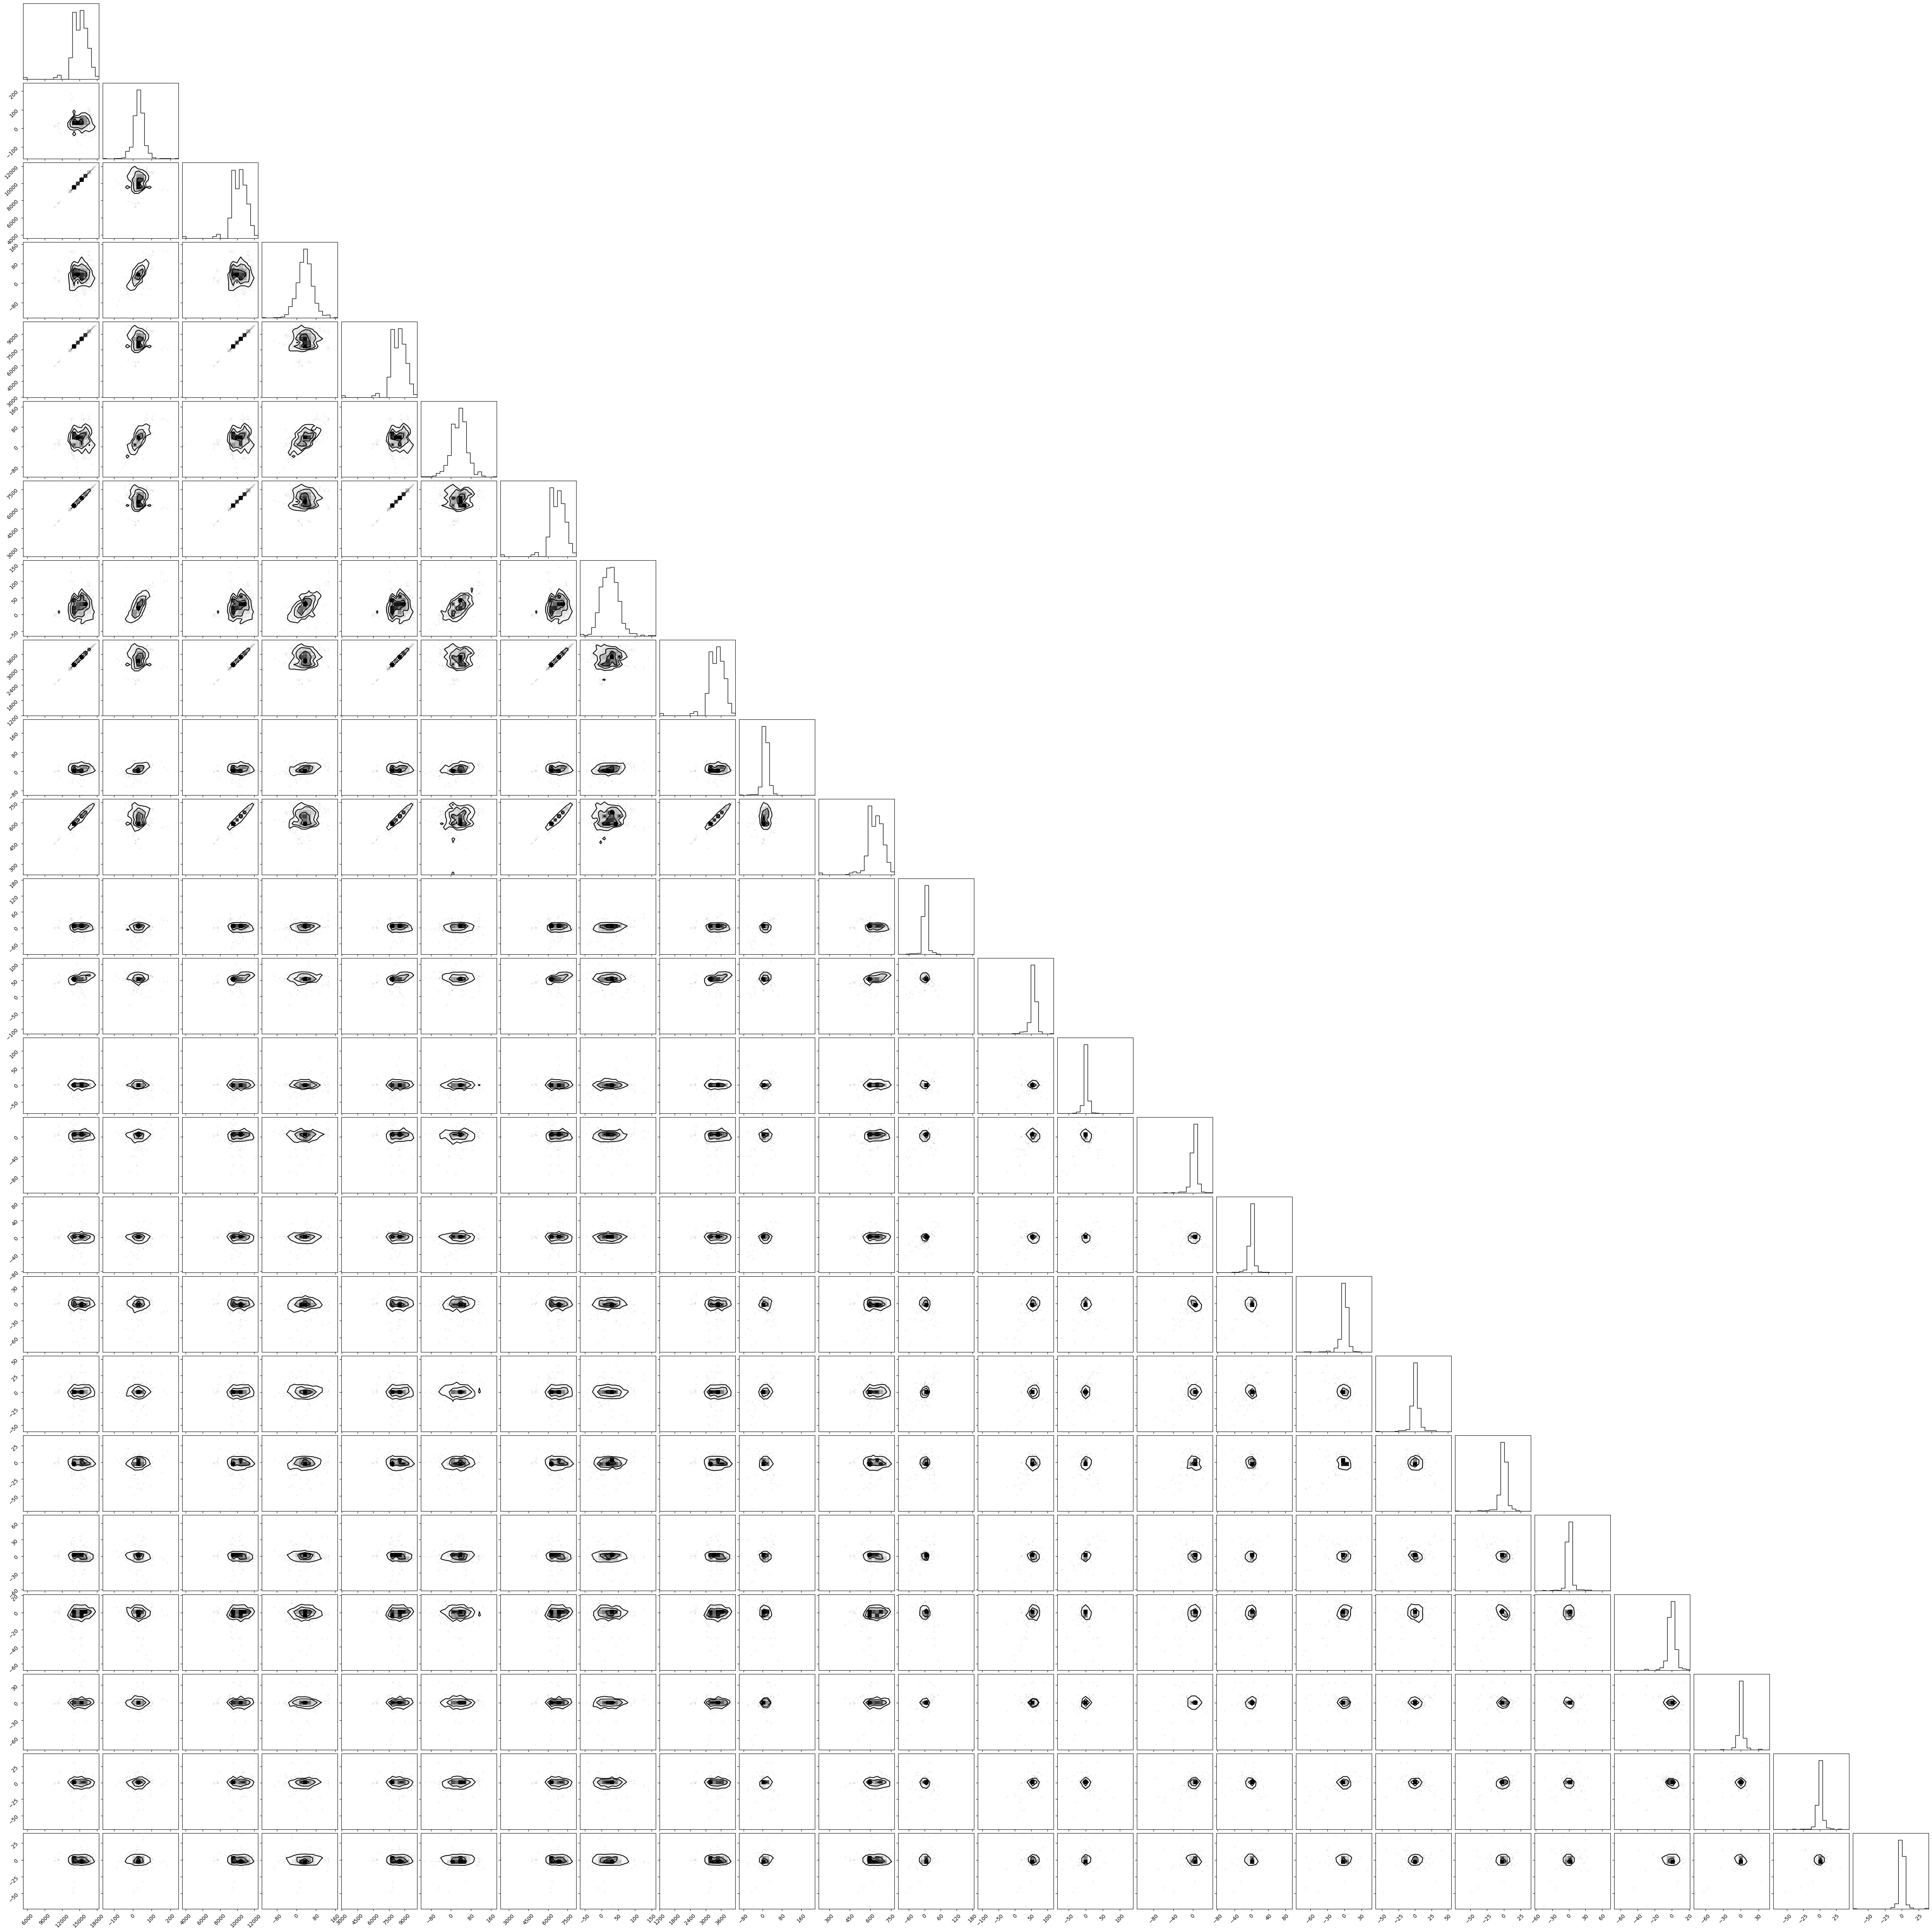

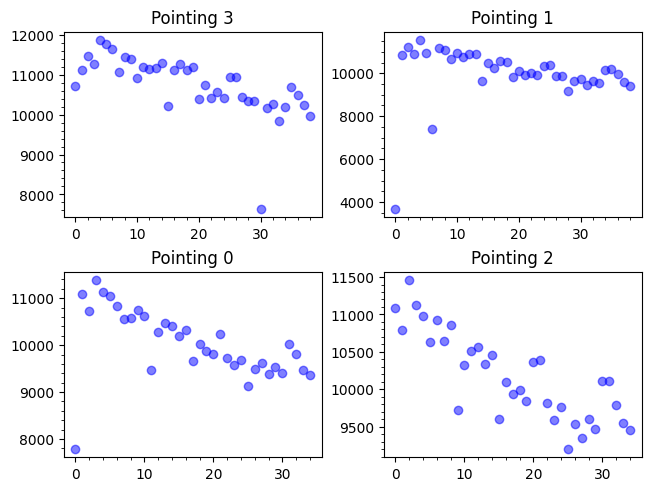

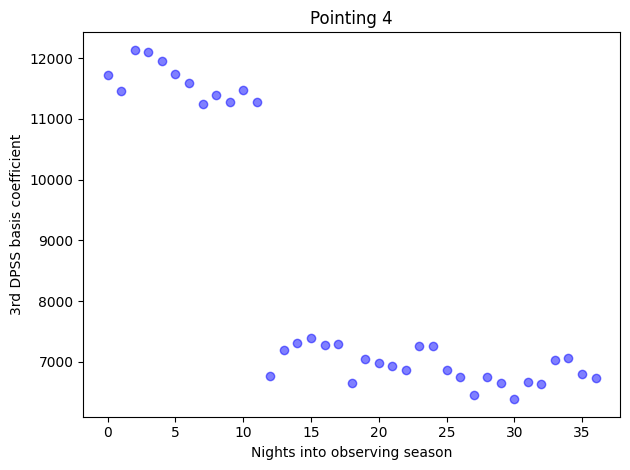

In [6]:
##Cornerplot of DPSS coefficients
c0 = np.load('Data/p0_coefficients.npy')
c1 = np.load('Data/p1_coefficients.npy')
c2 = np.load('Data/p2_coefficients.npy')
c3 = np.load('Data/p3_coefficients.npy')
c4 = np.load('Data/p4_coefficients.npy')
samples = np.concatenate((c0, c1, c2, c3))
figure = corner.corner(samples)

##Plotting coefficients v.s. time, pointings 0-3
fig, ax = plt.subplots(ncols=2, nrows=2, constrained_layout=True)
ax[0, 0].minorticks_on()
ax[1, 0].minorticks_on()
ax[0, 1].minorticks_on()
ax[1, 1].minorticks_on()
ax[0, 0].scatter(np.arange(len(c3[::4])), c3[:, 2][::4], alpha=0.5, label='p3', color='blue')
ax[0, 0].set_title("Pointing 3")
ax[0, 1].scatter(np.arange(len(c1[::4])), c1[:, 2][::4], alpha=0.5, label='p1', color='blue')
ax[0, 1].set_title("Pointing 1")
ax[1, 0].scatter(np.arange(len(c0[::4])), c0[:, 2][::4], alpha=0.5, label='p0', color='blue')
ax[1, 0].set_title("Pointing 0")
ax[1, 1].scatter(np.arange(len(c2[::4])), c2[:, 2][::4], alpha=0.5, label='p2', color='blue')
ax[1, 1].set_title("Pointing 2")
plt.show()

##Plotting coefficients from pointing 4
plt.scatter(np.arange(len(c4[::4])), c4[:, 2][::4], alpha=0.5, label='p2', color='blue')
plt.title("Pointing 4")
plt.xlabel('Nights into observing season')
plt.ylabel('3rd DPSS basis coefficient')
plt.tight_layout()
plt.show()

In [7]:
##Setting up the padding for the gaps
dt = st.mode(np.diff(time)).mode
smooth_time = np.arange(time.min(), time.max() + dt, dt)
padded_amp = np.full_like(smooth_time, np.nan, dtype=float)
indices = np.searchsorted(smooth_time, time)
padded_amp[indices] = amp

##Defining the rcos_diff model

def rcos_diff(params, time, vis_amp, show_converg=False, N_terms=13):


    '''
    The rcos_diff function. Used to define emissions according to the raised cosine model.

    Args:
        params          -- Input parameters, concatenated as np.concantenate((coeff, theta))
        time            -- (Gappy) time
        vis_amp         -- Padded amplitudes
        show_converg    -- Boolean, whether we want
        N_terms         -- Length of polynomial basis used for the background
    '''

    #Making our DPSS fit coefficients and emission parameters
    coeff = params[:N_terms]
    theta = params[N_terms:]
    
    #Constructing our DPSS basis
    NW, K = 4, N_terms
    design = dpss(len(time), NW, K).T
    background = design @ coeff

    #Building our emissions
    emission = np.zeros_like(time)
    if len(theta) > 0:
        num_emissions = len(theta) // 3
    else:
        num_emissions = 0

    if len(theta) % 3 != 0:
        raise ValueError("Incorrect array size for Gaussian fit parameters.")

    for k in range(num_emissions):
        amp, mu, sigma = theta[3*k : 3*k + 3]
        mask = np.abs(time - mu) <= sigma
        emission[mask] += amp / 2 * (1 + np.cos(np.pi*(time[mask] - mu)/sigma))

    #Defining the joint model
    amp_fit = background + emission

    #Defining our residuals
    mask = np.isfinite(vis_amp)
    mod_res = amp_fit[mask] - vis_amp[mask]
    
    #Constructing the noise:
    C = 4/np.pi - 1
    noise_var = (amp_fit[mask]**2) * C / (N_bl * N_freq) + 1e-5

    #Now we can build our log likelihood:
    log_like = -0.5 * (
        np.sum(mod_res**2 / noise_var) +  # Quadratic term
        np.sum(np.log(noise_var)) +         # Log determinant
        len(mod_res) * np.log(2*np.pi)    # Normalization
    )


    #Determining prior mean and covariance for DPSS coefficients
    prior_mean = np.mean(samples[:, :N_terms], axis=0)
    prior_cov = np.cov(samples[:, :N_terms].T)
    
    prior_residual = coeff - prior_mean
    
    
    # Full prior construction for coefficients
    L = la.cholesky(prior_cov, lower=True)
    alpha = la.solve_triangular(L, prior_residual, lower=True)
    log_prior_coeff = -0.5 * (
        alpha @ alpha +
        2 * np.sum(np.log(np.diag(L))) +
        N_terms * np.log(2*np.pi)
    )

    
    #Determining prior mean and covariance for emission coefficients
    emit_mean = np.mean(theta_0[[0, 2]], axis=1)
    emit_cov = la.block_diag(*[np.cov(theta_0[[0, 2]])] * num_emissions)

    mask = np.arange(len(theta)) % 3 != 1
    emit_residual = theta[mask] - np.tile(emit_mean, num_emissions)

    # Full prior construction for emission parameters
    if num_emissions > 0:
        L = la.cholesky(emit_cov, lower=True)
        alpha = la.solve_triangular(L, emit_residual, lower=True)
        log_prior_emit = -0.5 * (
            alpha @ alpha +
            2 * np.sum(np.log(np.diag(L))) +
            len(theta) * np.log(2*np.pi)
        )
    else:
        log_prior_emit=0

    # Printing value of minus log posterior
    if show_converg==True:
        print(-(log_like + log_prior_coeff + log_prior_emit), end='\r')
        
    return -(log_like + log_prior_coeff + log_prior_emit + 100*num_emissions)

In [8]:
##Constructing optimizer -- this works by "seeding" guesses on a regular division of the time array and testing whether there is an emission there

from itertools import combinations

N_terms = 13 
smooth_time = smooth_time - np.min(smooth_time[np.isfinite(smooth_time)]) #shifting time array
divs = 12 #how many seeding spots; increase if it isn't sampling enough, decrease if too slow

#Setting threshold -- if there is a min-fit undefined error, set this higher
min_prob=100000

#Defining our lower and upper bounds on how many emissions we're testing for
lower, upper = 0, 1

#Starting the loop -- "probe" seed combos to look for what has minimum log posterior, then paring down on that
for num_emissions in range(0, upper + 1):

    #Initializing arrays
    print(f"Testing {num_emissions} emissions.")
    log_prob = np.array([])
    time_fits = np.empty((0, N_terms + 3*num_emissions))

    #Defining seeds -- combinations of seeding spots
    seeds = np.linspace(smooth_time.min(), smooth_time.max(), divs)
    combos = np.array(list(combinations(seeds, num_emissions)))
    print("Number of seeds:", len(combos))

    #Looping
    for x in range(len(combos)):

        #Setting up emission guess
        print("Running cycle #", x + 1)
        emit_array = []
        for j in np.arange(0, num_emissions):
            emit_array = np.concatenate((emit_array, [np.mean(theta_0[0]), combos[x, j], np.mean(theta_0[2])]))
        
        #Setting up initial guess and parameter bounds
        p0 = np.concatenate((np.mean(samples[:, :N_terms], axis=0), emit_array))
        bounds = (
            [(-1e5, 1e5)] * N_terms +
            ([(theta_0[0].min(), theta_0[0].max()), (0, smooth_time.max()), (theta_0[2].min(), smooth_time.max())] * num_emissions)
        )

        #Minimizing raised cosine fit
        rcos_fit = minimize(
            lambda p: rcos_diff(p, smooth_time, padded_amp),
            x0=p0,
            bounds=bounds,
            method='Nelder-Mead',
            options={
                'maxfev': 500,
                'adaptive': True,  
                'xatol': 1e-6,     
                'fatol': 1e-5
            }
        ).x

        #Calculating log posteriors
        log_prob_min = rcos_diff(rcos_fit, smooth_time, padded_amp)
        log_prob = np.append(log_prob, log_prob_min)
        time_fits = np.vstack([time_fits, rcos_fit])

    #Minimum log posterior for set number of seeding places
    rcos_fit = time_fits[log_prob == np.min(log_prob)][0]
    print(f"Minimum log posterior found for {num_emissions} emissions is {log_prob.min()}.")

    #Updating if log posterior is found to be smaller than previous
    if log_prob.min() < min_prob:
        min_prob = log_prob.min()
        min_fit = rcos_fit

#Starting final run
p0 = min_fit
num_emissions = int((len(p0) - 13)/3)
bounds = (
            [(-1e5, 1e5)] * N_terms +
            ([(theta_0[0].min(), theta_0[0].max()), (0, smooth_time.max()), (theta_0[2].min(), smooth_time.max())] * num_emissions)
        )

rcos_fit = minimize(
        lambda p: rcos_diff(p, smooth_time, padded_amp, show_converg=True),
        x0=p0,
        bounds=bounds,
        method='Nelder-Mead',
        options={
            'maxfev': 20000,
            'adaptive': True,  
            'xatol': 1e-6,     
            'fatol': 1e-5
        }
    ).x

print(rcos_diff(rcos_fit, smooth_time, padded_amp))
print(rcos_fit)

Testing 0 emissions.
Number of seeds: 1
Running cycle # 1
Minimum log posterior found for 0 emissions is 218221.73109394338.
Testing 1 emissions.
Number of seeds: 12
Running cycle # 1
Running cycle # 2
Running cycle # 3
Running cycle # 4
Running cycle # 5
Running cycle # 6
Running cycle # 7
Running cycle # 8
Running cycle # 9
Running cycle # 10
Running cycle # 11
Running cycle # 12
Minimum log posterior found for 1 emissions is 16964.743960918146.
1482.5073614861158
[1.48613215e+04 3.89609961e+01 1.01149710e+04 1.73908705e+01
 8.29550421e+03 7.91210436e+01 6.66685592e+03 3.09160592e+01
 3.39294829e+03 1.90044756e+00 6.22212347e+02 3.46965819e+00
 5.69793324e+01 5.17251929e+01 1.19528389e-02 7.91214414e-04]


[5.17251929e+01 1.19528389e-02 7.91214414e-04]


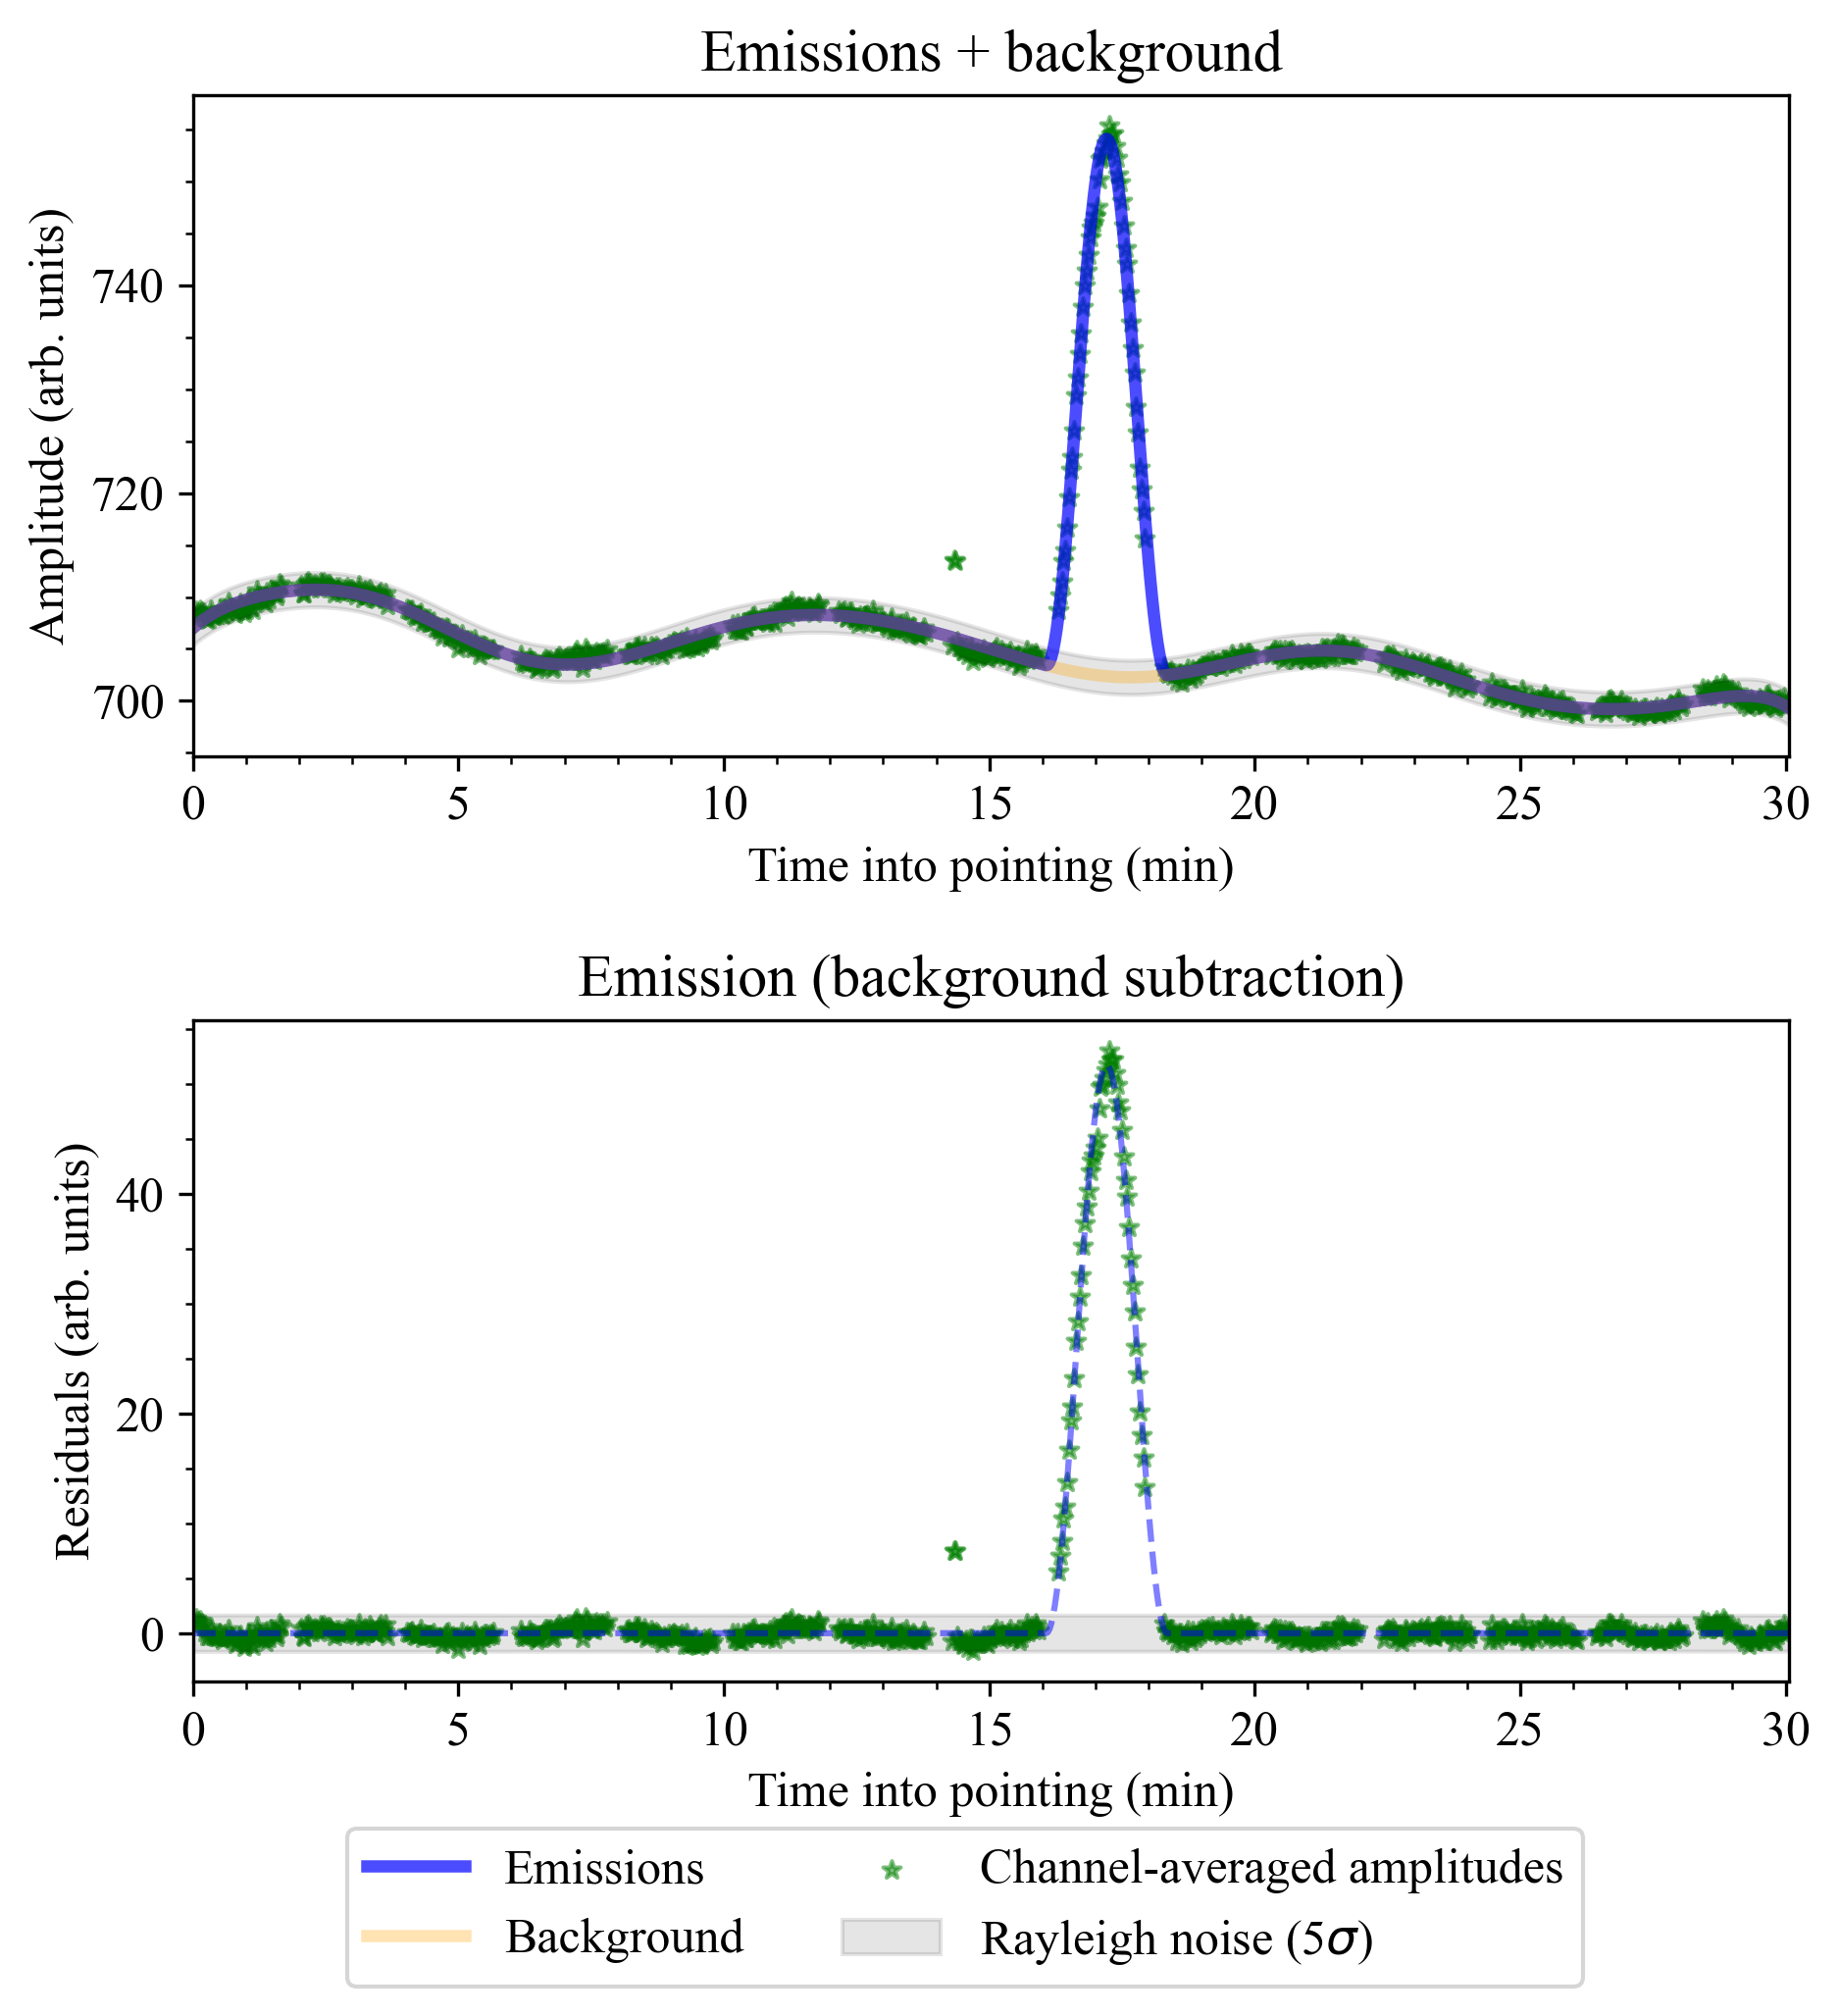

In [9]:
def rcos_model(time, *params, show='all', N_terms=13):

    '''
    The rcos_model, allows us to plot the model

    Args:
        time        -- Smooth uniform time array, gapless
        params      -- Parameters returned by rcos_fit
        show        -- 'emit' for emissions only, 'background' for smooth background only, 'all' for both
        N_terms     -- Number of background terms
    '''

    #Separating parameters
    coeff = params[:N_terms]
    theta = params[N_terms:]
    
    #Defining smooth background
    NW, K = 4, N_terms   
    basis = dpss(len(time), NW, K)
    design = basis.T
    background = design @ coeff

    #Constructing emissions
    emission = np.zeros_like(time)
    num_emissions = len(theta) // 3
    if len(theta) % 3 != 0:
        raise ValueError("Incorrect array size for Gaussian fit parameters.")
    for k in range(num_emissions):
        amp, mu, sigma = theta[3*k : 3*k + 3]
        mask = np.where(np.abs(time - mu) <= sigma, True, False)
        emission[mask] += amp / 2 * (1 + np.cos(np.pi*(time[mask] - mu)/sigma))
        
    #Returning what we want
    if show == 'all':
        return background + emission
    elif show == 'emit':
        return emission
    elif show == 'background':
        return background

##Some plotting code
print(rcos_fit[N_terms:])
plt.style.use('default')
plt.rcParams.update({'font.size': 12,
                     'font.family': 'serif',
                     'font.serif': 'Times New Roman'})

figure, ax = plt.subplots(ncols=1, nrows=2, dpi=300, figsize=(7, 7))
ax[0].set_title("Emissions + background")
ax[0].plot(smooth_time*60*24, rcos_model(smooth_time, *rcos_fit), color='blue', alpha=0.7, lw=3, linestyle='-', label='Emissions')
ax[0].plot(smooth_time*60*24, rcos_model(smooth_time, *rcos_fit, show='background'), color='orange', alpha=0.3, lw=3, label = 'Background')
ax[0].set_xlabel("Time into pointing (min)")
ax[0].set_ylabel("Amplitude (arb. units)")
ax[0].scatter(smooth_time*60*24, padded_amp, s=20, alpha=0.5, color='green', label='Channel-averaged amplitudes', marker='*')
ax[0].fill_between(smooth_time*60*24, 
                 -5*np.sqrt((4/np.pi-1)/N_bl/N_freq)*rcos_model(smooth_time, *rcos_fit, show='background') + rcos_model(smooth_time, *rcos_fit, show='background'),
                 5*np.sqrt((4/np.pi-1)/N_bl/N_freq)*rcos_model(smooth_time, *rcos_fit, show='background') + rcos_model(smooth_time, *rcos_fit, show='background'),
                 alpha = 0.1, color = 'black', label = r'Rayleigh noise (5$\sigma$)')
ax[0].set_xlim(smooth_time.min()*60*24, smooth_time.max()*60*24)
figure.legend(bbox_to_anchor=(0.5, -0.05), loc = 'lower center', ncol=2)
plt.subplots_adjust(hspace=0.4)
fig.set_tight_layout('tight')

ax[1].set_title('Emission (background subtraction)')
ax[1].set_xlabel("Time into pointing (min)")
ax[1].plot(smooth_time*60*24, rcos_model(smooth_time, *rcos_fit, show='emit'), color='blue', alpha=0.5, label = 'Emissions', linestyle='--')
ax[1].set_ylabel("Residuals (arb. units)")
ax[1].scatter(smooth_time*60*24, padded_amp - rcos_model(smooth_time, *rcos_fit, show='background'), s=20, alpha=0.5, color='green', label='Residuals', marker='*')
ax[1].fill_between(smooth_time*60*24, 
                 -5*np.sqrt((4/np.pi-1)/N_bl/N_freq)*rcos_model(smooth_time, *rcos_fit, show='background'),
                 5*np.sqrt((4/np.pi-1)/N_bl/N_freq)*rcos_model(smooth_time, *rcos_fit, show='background'),
                 alpha = 0.1, color = 'black', label = r'Rayleigh noise (5$\sigma$)')
ax[1].set_xlim(smooth_time.min()*60*24, smooth_time.max()*60*24)

ax[0].minorticks_on()
ax[1].minorticks_on()
plt.show()